# BloodAI — Monitor Fine-tuningu
Uruchamiaj komórki po kolei. Live-loop zatrzymaj przez **Kernel → Interrupt**.

In [1]:
import re, time, subprocess, ast
from IPython.display import clear_output
import matplotlib.pyplot as plt

LOG_FILE = '/tmp/finetune.log'
PID      = 10086
TOTAL_STEPS_PER_EPOCH = 12757
N_EPOCHS  = 5

def read_raw_segments():
    """tqdm pisze \\r bez \\n — splitujemy po bajtach."""
    data = open(LOG_FILE, 'rb').read()
    return [s.decode('utf-8', errors='ignore')
            for s in data.replace(b'\r\n', b'\n').split(b'\r')]

def parse_dicts(segs):
    """Wyciąga słowniki Pythona z logów (train + eval)."""
    train, evl = [], []
    for seg in segs:
        for m in re.finditer(r'\{[^{}]+\}', seg):
            try:
                d = ast.literal_eval(m.group())
            except Exception:
                continue
            if not isinstance(d, dict):
                continue
            if 'eval_loss' in d:
                evl.append(d)
            elif 'loss' in d and 'learning_rate' in d:
                train.append(d)
    return train, evl

def current_step(segs):
    for seg in reversed(segs):
        m = re.search(r'\|\s*(\d+)/(\d+)\s*\[', seg)
        if m:
            return int(m.group(1)), int(m.group(2))
    return 0, TOTAL_STEPS_PER_EPOCH

def clean_lines(segs, n=20):
    skip = ('it/s', 'BertSdpa', 'FutureWarn', 'warnings.warn',
            'You should probably', 'Some weights')
    keep = [s.strip() for s in segs if s.strip() and not any(x in s for x in skip)]
    return '\n'.join(keep[-n:])

def is_alive():
    r = subprocess.run(['ps', '-p', str(PID)], capture_output=True, text=True)
    return str(PID) in r.stdout

print('OK — konfiguracja zaladowana')

OK — konfiguracja zaladowana


## 1. Szybki status

In [2]:
segs  = read_raw_segments()
step, _ = current_step(segs)
total = TOTAL_STEPS_PER_EPOCH * N_EPOCHS
alive = is_alive()

print(f'Proces {PID}: {"DZIALA" if alive else "ZATRZYMANY"}')
print(f'Postep: {step:,}/{total:,} krokow  ({step/total*100:.1f}%)')
print(f'Epoka:  ~{step/TOTAL_STEPS_PER_EPOCH:.2f} / {N_EPOCHS}')
print()
print(clean_lines(segs, 20))

Proces 10086: DZIALA
Postep: 908/63,785 krokow  (1.4%)
Epoka:  ~0.07 / 5




## 2. Train loss (co 50 krokow)

In [3]:
segs = read_raw_segments()
train_dicts, _ = parse_dicts(segs)

if not train_dicts:
    print('Brak danych — czekaj na pierwsze 50 krokow.')
else:
    print(f'Krokow z metrykami: {len(train_dicts)}')
    print(f'Ostatnia train loss: {train_dicts[-1]["loss"]:.4f}  |  epoch: {train_dicts[-1]["epoch"]:.3f}')
    print()
    print(f'{"Epoch":<8} {"Loss":<10} {"LR"}')
    print('-'*35)
    for d in train_dicts[-10:]:
        print(f'{d["epoch"]:<8.3f} {d["loss"]:<10.4f} {d["learning_rate"]:.2e}')

Brak danych — czekaj na pierwsze 50 krokow.


## 3. Metryki eval per epoka (dostepne po ~2h)

In [4]:
segs = read_raw_segments()
_, eval_dicts = parse_dicts(segs)

if not eval_dicts:
    print('Brak metryk eval — pojawia sie po pierwszej epoce.')
else:
    print(f'{"Epoka":<7} {"macro AUC":<12} {"Eval Loss":<12} {"ECE":<10} {"SOR AUC":<10} {"NEFRO AUC"}')
    print('-'*65)
    for d in eval_dicts:
        print(f'{d.get("epoch","?"):<7} '
              f'{d.get("eval_macro_roc_auc",0):<12.4f} '
              f'{d.get("eval_loss",0):<12.4f} '
              f'{d.get("eval_ece",0):<10.4f} '
              f'{d.get("eval_roc_auc_SOR",0):<10.4f} '
              f'{d.get("eval_roc_auc_NEFRO",0):.4f}')

Brak metryk eval — pojawia sie po pierwszej epoce.


## 4. Wykresy

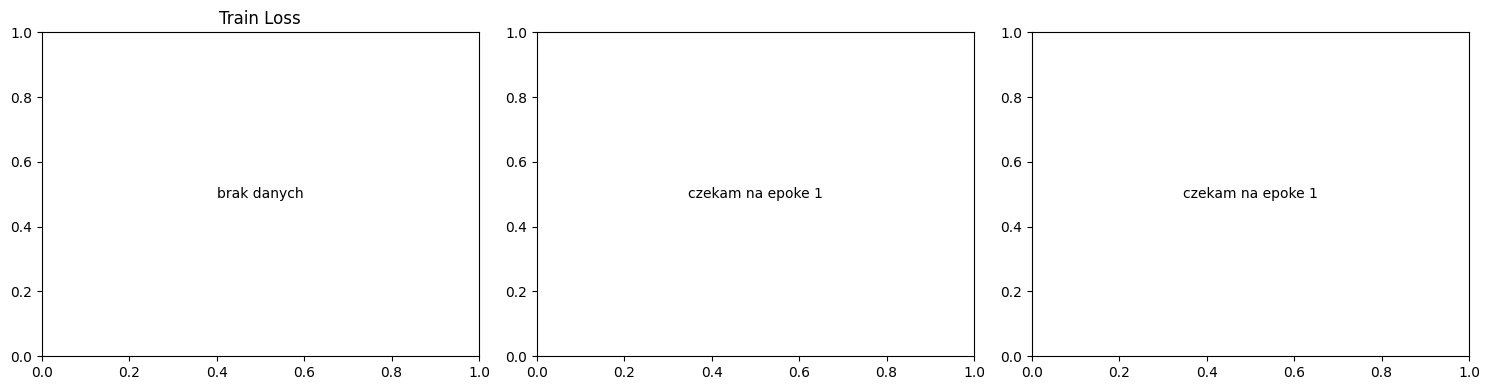

In [5]:
segs = read_raw_segments()
train_dicts, eval_dicts = parse_dicts(segs)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

if train_dicts:
    xs = [d['epoch'] for d in train_dicts]
    ys = [d['loss']  for d in train_dicts]
    axes[0].plot(xs, ys, color='steelblue', linewidth=0.9)
    axes[0].set_title('Train Loss')
    axes[0].set_xlabel('Epoka')
    axes[0].set_ylabel('Loss')
    axes[0].grid(alpha=0.3)
else:
    axes[0].text(0.5, 0.5, 'brak danych', ha='center', va='center', transform=axes[0].transAxes)
    axes[0].set_title('Train Loss')

if eval_dicts:
    xs  = [d.get('epoch', i+1) for i, d in enumerate(eval_dicts)]
    auc = [d.get('eval_macro_roc_auc', 0) for d in eval_dicts]
    axes[1].plot(xs, auc, 'o-', color='green', linewidth=2)
    axes[1].axhline(0.90, color='red', linestyle='--', alpha=0.5, label='cel 0.90')
    axes[1].set_title('Macro ROC AUC (eval)')
    axes[1].set_xlabel('Epoka')
    axes[1].set_ylim(0.5, 1.0)
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    last   = eval_dicts[-1]
    cls    = ['POZ','GASTRO','HEMATO','NEFRO','SOR','CARDIO','PULMO','HEPATO']
    aucs   = [last.get(f'eval_roc_auc_{c}', 0) for c in cls]
    colors = ['red' if c == 'SOR' else 'steelblue' for c in cls]
    axes[2].bar(cls, aucs, color=colors)
    axes[2].axhline(0.90, color='gray', linestyle='--', alpha=0.5)
    axes[2].set_title(f'AUC per klasa (epoka {last.get("epoch","?"):.0f})')
    axes[2].set_ylim(0, 1.05)
    axes[2].tick_params(axis='x', rotation=30)
    axes[2].grid(axis='y', alpha=0.3)
else:
    for ax in axes[1:]:
        ax.text(0.5, 0.5, 'czekam na epoke 1', ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
plt.show()

## 5. Live monitor (Kernel > Interrupt zeby zatrzymac)

In [6]:
REFRESH = 60

while True:
    clear_output(wait=True)
    segs  = read_raw_segments()
    alive = is_alive()
    step, _ = current_step(segs)
    total   = TOTAL_STEPS_PER_EPOCH * N_EPOCHS
    train_dicts, eval_dicts = parse_dicts(segs)

    status = 'DZIALA' if alive else 'ZATRZYMANY'
    print(f'[{time.strftime("%H:%M:%S")}]  PID {PID}: {status}')
    bar_w  = 40
    filled = int(bar_w * step / total) if total else 0
    print(f'[{"#"*filled}{"."*(bar_w-filled)}] {step:,}/{total:,}  ({step/total*100:.1f}%)  epoka ~{step/TOTAL_STEPS_PER_EPOCH:.2f}/{N_EPOCHS}')

    if train_dicts:
        last = train_dicts[-1]
        print(f'Ostatnia train loss: {last["loss"]:.4f}  (epoch {last["epoch"]:.3f})')

    if eval_dicts:
        print(f'\n{"Epoka":<7} {"macro AUC":<12} {"SOR AUC":<10} {"ECE"}')
        for d in eval_dicts:
            print(f'{d.get("epoch","?"):<7} {d.get("eval_macro_roc_auc",0):<12.4f} '
                  f'{d.get("eval_roc_auc_SOR",0):<10.4f} {d.get("eval_ece",0):.4f}')
    else:
        print('\nCzekam na pierwsza epoké...')

    print('\n--- Ostatnie logi ---')
    print(clean_lines(segs, 10))

    if not alive:
        print('\nTrening zakonczony! Sprawdz checkpoints/finetune/')
        break

    time.sleep(REFRESH)

[13:33:05]  PID 10086: ZATRZYMANY
[#.......................................] 2,032/63,785  (3.2%)  epoka ~0.16/5
Ostatnia train loss: 0.6630  (epoch 1.000)

Czekam na pierwsza epoké...

--- Ostatnie logi ---
52%|█████▏    | 2032/3919 [56:38<2:13:13,  4.24s/it]

Trening zakonczony! Sprawdz checkpoints/finetune/


## 6. Checkpointy

In [7]:
import os
CKPT = '/Users/antonio/ClaudeHackathon-Repo /BloodAI-Hackathon-Claude/checkpoints/finetune'
if not os.path.exists(CKPT):
    print('Brak katalogu checkpointow.')
else:
    items = sorted(os.listdir(CKPT))
    if not items:
        print('Katalog istnieje ale pusty — brak zapisanych checkpointow.')
    for item in items:
        full = os.path.join(CKPT, item)
        if os.path.isdir(full):
            size = sum(os.path.getsize(os.path.join(full, f))
                       for f in os.listdir(full) if os.path.isfile(os.path.join(full, f)))
            print(f'{item:<35}  {size/1e6:.0f} MB')
        else:
            print(item)

Katalog istnieje ale pusty — brak zapisanych checkpointow.
